# Datashader reductions in spatialdata-plot

The datashader backend renders large data by binning primitives onto a pixel grid. When several points
fall in the same pixel and you colour by a **continuous** column, datashader has to combine their
values into one — and `datashader_reduction` chooses how: take the maximum, the mean, the sum, a count,
and so on. By the end you should be able to:

- Understand why a continuous colour needs a reduction on the datashader backend.
- Compare `max`, `mean`, `sum`, `count`, and `std` and read them off the colorbar.
- Use `method="datashader"` for large images.
- Recognise the datashader contrast caveat.

We use the real Xenium `cells` dataset from `squidpy` (its `transcripts` element and the
`morphology_focus` image), downloaded and cached on first use.

> **Watch out:** on the datashader backend a `PercentileNormalize` does not clip to its percentiles —
> the single most common datashader-contrast surprise, covered in section 5.

## Setup

In [1]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sq.datasets.cells()
sdata

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


INFO     Loading existing dataset from data/spatialdata/cells.zarr                                                 


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/spatialdata/cells.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     ├── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'tissue_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Lab

The `cells` dataset is a small (~3&thinsp;MB) crop of a real 10x **Xenium** section (also used in the
*Colouring points* example). The reductions below aggregate its `transcripts` points, coloured by the
quality column `qv`:

In [2]:
list(sdata["transcripts"].columns)

['x',
 'y',
 'z',
 'feature_name',
 'cell_id',
 'fov_name',
 'codeword_index',
 'qv',
 'transcript_id',
 'is_gene',
 'codeword_category',
 'nucleus_distance',
 'overlaps_nucleus']

## 1. Why a reduction is needed

On the datashader backend the transcripts are aggregated into pixels. Colouring by the quality `qv`,
each pixel may cover many transcripts — `datashader_reduction` decides which value the pixel shows. The
default is `max`.

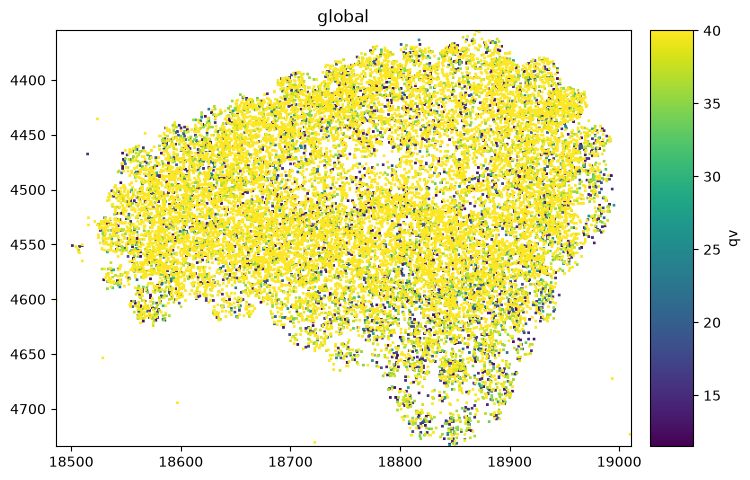

In [3]:
sdata.pl.render_points(
    "transcripts", color="qv", method="datashader", datashader_reduction="max"
).pl.show()

## 2. `max` vs `mean` vs `sum`

The reduction changes both the picture and the colorbar scale. `max` reports the single brightest value
in a pixel (bounded by the data max), `mean` averages, and `sum` accumulates — so its colorbar runs far
higher wherever transcripts pile up.

As a rule of thumb: `sum` for abundance, `mean` for a typical value, `max` for the brightest signal,
and `std` (below) for heterogeneity.

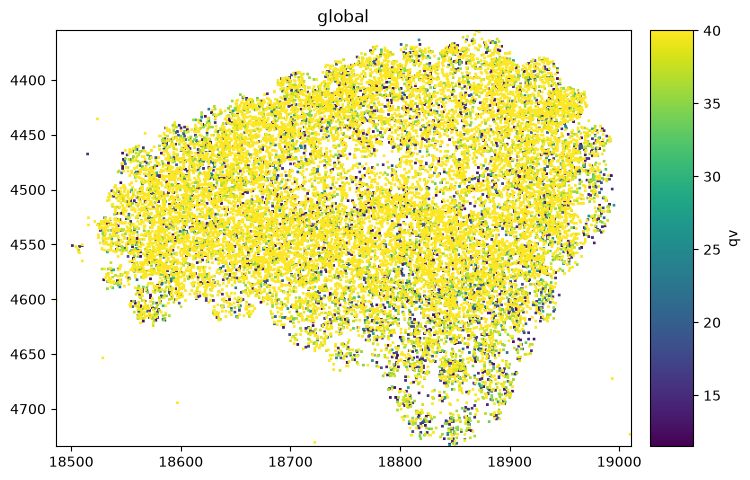

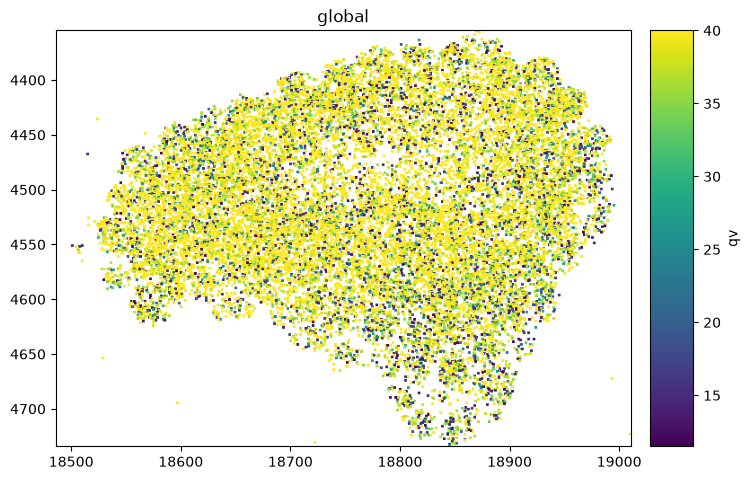

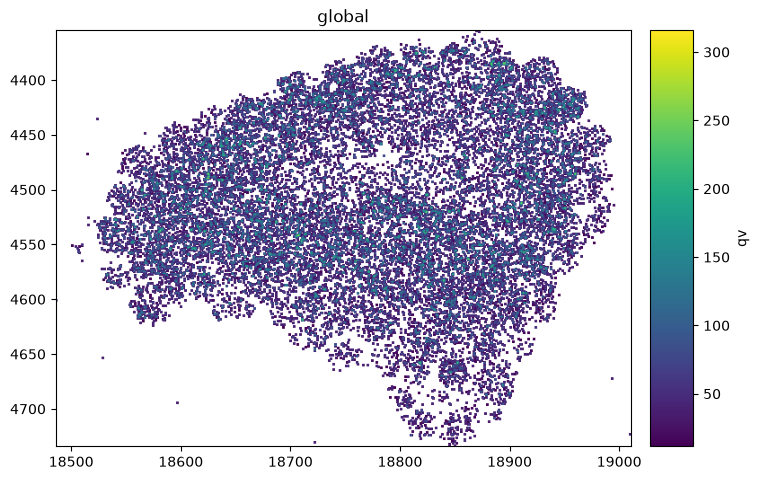

In [4]:
for reduction in ["max", "mean", "sum"]:
    sdata.pl.render_points(
        "transcripts", color="qv", method="datashader", datashader_reduction=reduction
    ).pl.show()

## 3. `count` and `std` — structure without a value column

`count` ignores the colour value and shows how many primitives fall in each pixel (a density — equivalent to
`density=True` with no `density_how`, as in the *Point density maps* notebook). `std` shows the spread of the values per pixel — useful for finding
heterogeneous regions.

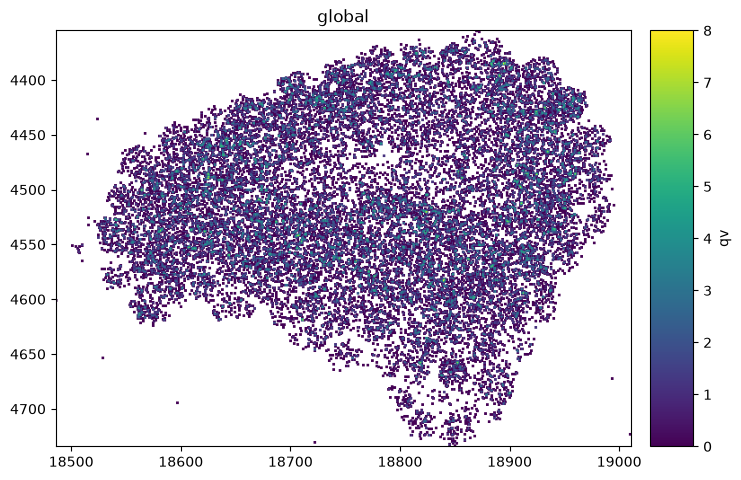

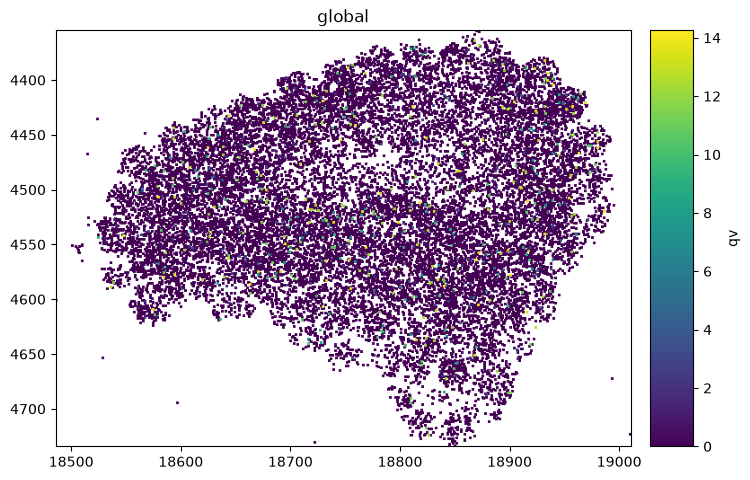

In [5]:
for reduction in ["count", "std"]:
    sdata.pl.render_points(
        "transcripts", color="qv", method="datashader", datashader_reduction=reduction
    ).pl.show()

## 4. Datashader for large images — `method="datashader"`

Reductions also apply to images: `method="datashader"` renders large or sparse rasters by aggregating
pixels, instead of handing the full array to matplotlib.

The image path takes a slightly different reduction vocabulary — it adds `mode`/`first`/`last` and has
no `count`/`any` — though here we leave `datashader_reduction` at its default.

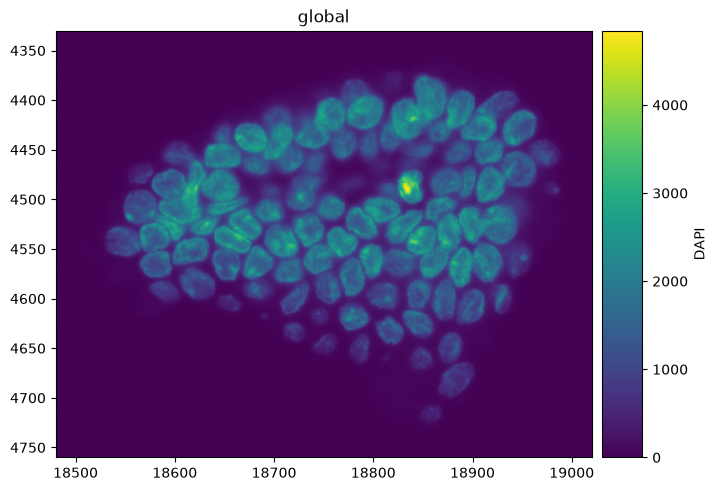

In [6]:
sdata.pl.render_images(
    "morphology_focus", channel="DAPI", method="datashader"
).pl.show()

## 5. The datashader contrast caveat

On the datashader backend, contrast autoscales to the **aggregated** value range, not to a norm's
percentiles — a `PercentileNormalize` does not clip the way it does on the matplotlib backend (see the
*Normalization and contrast* tutorial). Explicit `vmin`/`vmax` are still honoured. For
percentile-driven contrast, render on the matplotlib backend.

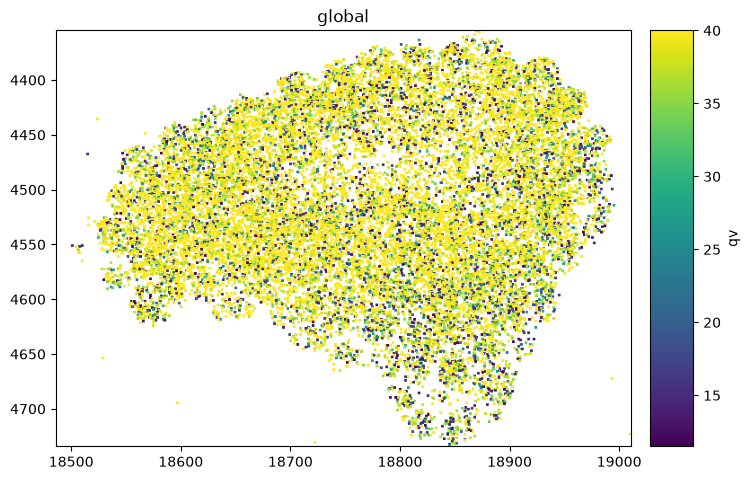

In [7]:
from spatialdata_plot import PercentileNormalize

# On datashader the percentile clip is not applied; contrast follows the aggregate range.
sdata.pl.render_points(
    "transcripts", color="qv", method="datashader",
    datashader_reduction="mean", norm=PercentileNormalize(5, 95),
).pl.show()

## Summary

- **Contrast caveat first:** datashader contrast follows the aggregate range, not norm percentiles —
  use the matplotlib backend when you need percentile (or any non-`vmin`/`vmax`) contrast.
- On the datashader backend, a continuous colour needs a **reduction** to combine the primitives that
  share a pixel; `datashader_reduction` sets it (default `max`).
- `max`/`mean`/`sum` change the picture and the colorbar scale; `count` gives a density (same as
  `density=True`) and `std` the per-pixel spread.
- `method="datashader"` applies to images too, for large or sparse rasters (with a slightly different
  reduction vocabulary).

## For reproducibility

In [8]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,datashader,matplotlib

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.2
datashader      : 0.19.1
matplotlib      : 3.11.0

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

